# Tier 2 — Notebook B (v3 + FS): German Credit (UCI 144)

**v3 architecture audience-ready notebook.**

**Changes vs the earlier v5 notebook:**
- **No skew kernels** anywhere (removed `SkewPNN` and `SkewSVM` from both base and meta layers).
- **5 base classifiers** (v3 lineup): RF, GB, XGB, KNN, SVM-RBF.
- **5 meta candidates** (v3 lineup): LR, RF, XGB, MLP, GA-MaxAccLogit.
- **Feature-selection sweep retained** (Full / RFE / Lasso-LR / Forward).

**What gets saved per run** (so we can compare runs later):
- 4 **sub-dataset CSVs** — one per FS variant — the actual `X_train + X_test + y + split` slices we feed to models. With the other 3 UCI datasets these will total **16 sub-datasets**.
- 4 **feature-list CSVs** — exact features each FS picks.
- **Per-section results CSVs** — base models, classical ensembles, stacker, and the final combined leaderboard.

**Dataset:** UCI 144 — German Credit (n=1000, 20 raw features → 48 after one-hot). Imbalanced **70% good / 30% bad** → SMOTE on every base+meta, GHOST threshold tuning at meta layer.

---

## §0  Environment setup

In [ ]:
import os, sys
from pathlib import Path

DRIVE_PROJECT_PATH = '/content/drive/MyDrive/CreditRiskApp'

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
    print('Detected Google Colab.')
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = Path(DRIVE_PROJECT_PATH)
    PROJECT_ROOT.mkdir(parents=True, exist_ok=True)
except ImportError:
    IN_COLAB = False
    print('Detected local environment.')
    NB_DIR = Path.cwd()
    PROJECT_ROOT = NB_DIR.parents[1] if NB_DIR.name == 'notebooks' else NB_DIR

RESULTS_DIR = PROJECT_ROOT / 'tier2_predictive_models' / 'results'
SUBSETS_DIR = PROJECT_ROOT / 'tier2_predictive_models' / 'fs_subsets'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
SUBSETS_DIR.mkdir(parents=True, exist_ok=True)
print(f'PROJECT_ROOT = {PROJECT_ROOT}')
print(f'RESULTS_DIR  = {RESULTS_DIR}')
print(f'SUBSETS_DIR  = {SUBSETS_DIR}')

Detected Google Colab.
Mounted at /content/drive
PROJECT_ROOT = /content/drive/MyDrive/CreditRiskApp
RESULTS_DIR  = /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/results
SUBSETS_DIR  = /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/fs_subsets


### Configuration

In [ ]:
DATASET       = 'german'
UCI_ID        = 144
USE_SMOTE     = True       # imbalanced (70/30) → wrap every base + meta in ImbPipeline(SMOTE → clf)
RANDOM_STATE  = 42
CV_FOLDS      = 5
N_ITER_BAYES  = 20
SMOTE_K       = 5

# Tag prefix for every CSV this notebook saves
RUN_TAG       = 'german_v3'

print(f"Dataset: {DATASET} (UCI id={UCI_ID})")
print(f"USE_SMOTE: {USE_SMOTE}  CV folds: {CV_FOLDS}  Bayes iter: {N_ITER_BAYES}")
print(f"RUN_TAG: {RUN_TAG}")

Dataset: german (UCI id=144)
USE_SMOTE: True  CV folds: 5  Bayes iter: 20
RUN_TAG: german_v3


### Install dependencies

In [ ]:
!pip install ucimlrepo xgboost imbalanced-learn ghostml scikit-optimize -q
print('Libraries installed!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.2 MB/s eta 0:00:00
Libraries installed!


### Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from ucimlrepo import fetch_ucirepo

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, cohen_kappa_score
from sklearn.base import BaseEstimator, ClassifierMixin

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.feature_selection import RFE, SelectFromModel, SequentialFeatureSelector
from xgboost import XGBClassifier
import ghostml

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from skopt import BayesSearchCV
from skopt.space import Real, Integer

print('Imports done.')

Imports done.


### Custom class — `MaxAccLogit`

Genetic-algorithm-tuned logistic regression. Used as one of the 5 meta candidates in the Stacker.
**No skew kernel classes here** — this is the v3 architecture without `SkewPNN` / `SkewSVM`.

In [ ]:
class MaxAccLogit(BaseEstimator, ClassifierMixin):
    def __init__(self, lambda_reg=0.01, pop_size=None, n_gen=300,
                 p_crossover=0.8, p_mutation=0.1, elite_frac=0.05,
                 bound=3.0, early_stop=50, scoring='f1_macro', random_state=42):
        self.lambda_reg, self.pop_size, self.n_gen = lambda_reg, pop_size, n_gen
        self.p_crossover, self.p_mutation, self.elite_frac = p_crossover, p_mutation, elite_frac
        self.bound, self.early_stop, self.scoring = bound, early_stop, scoring
        self.random_state = random_state
    def _sigmoid(self, z): return 1.0 / (1.0 + np.exp(-np.clip(z, -50, 50)))
    def _predict_with(self, theta, X): return self._sigmoid(X @ theta[1:] + theta[0])
    def _fitness(self, theta, X, y):
        prob = self._predict_with(theta, X); pred = (prob >= 0.5).astype(int)
        s = f1_score(y, pred, average='macro') if self.scoring == 'f1_macro' else accuracy_score(y, pred)
        return s - self.lambda_reg * np.abs(theta[1:]).sum()
    def _soft_threshold(self, theta):
        b0, b = theta[0], theta[1:]
        b = np.sign(b) * np.maximum(np.abs(b) - self.lambda_reg, 0.0)
        return np.concatenate([[b0], b])
    def fit(self, X, y):
        rng = np.random.default_rng(self.random_state)
        X = np.asarray(X, dtype=float); y = np.asarray(y, dtype=int)
        n, p = X.shape; chrom_len = p + 1
        pop_size = self.pop_size if self.pop_size else 10 * chrom_len
        n_elite = max(1, int(self.elite_frac * pop_size))
        pop = rng.uniform(-self.bound, self.bound, size=(pop_size, chrom_len))
        for i in range(pop_size): pop[i] = self._soft_threshold(pop[i])
        fit_arr = np.array([self._fitness(t, X, y) for t in pop])
        best_history, no_improve = [], 0
        for gen in range(self.n_gen):
            f_min, f_max, f_mean = fit_arr.min(), fit_arr.max(), fit_arr.mean()
            C = 2.0; denom = f_max - f_mean if f_max != f_mean else 1e-10
            if f_min > (C * f_mean - f_max) / max(C - 1, 1e-10):
                a = f_mean * (C - 1) / denom
                b = f_mean * (f_max - C * f_mean) / denom
            else:
                d = f_mean - f_min if f_mean != f_min else 1e-10
                a = f_mean / d; b = -f_mean * f_min / d
            scaled = np.maximum(a * fit_arr + b, 1e-10)
            probs = scaled / scaled.sum()
            sel = rng.choice(pop_size, size=pop_size, p=probs)
            mating = pop[sel].copy()
            for i in range(0, pop_size - 1, 2):
                if rng.random() < self.p_crossover:
                    w = rng.uniform(0, 1, size=chrom_len)
                    p1, p2 = mating[i].copy(), mating[i+1].copy()
                    mating[i]   = w * p1 + (1 - w) * p2
                    mating[i+1] = (1 - w) * p1 + w * p2
            for i in range(pop_size):
                if rng.random() < self.p_mutation:
                    j = rng.integers(0, chrom_len)
                    mating[i, j] = rng.uniform(-self.bound, self.bound)
            for i in range(pop_size):
                mating[i] = self._soft_threshold(mating[i])
            new_fit = np.array([self._fitness(t, X, y) for t in mating])
            elite_idx_old = np.argsort(fit_arr)[-n_elite:]
            worst_idx_new = np.argsort(new_fit)[:n_elite]
            mating[worst_idx_new]  = pop[elite_idx_old]
            new_fit[worst_idx_new] = fit_arr[elite_idx_old]
            pop, fit_arr = mating, new_fit
            best = fit_arr.max(); best_history.append(best)
            if len(best_history) > 1 and best <= best_history[-2] + 1e-8:
                no_improve += 1
                if no_improve >= self.early_stop: break
            else:
                no_improve = 0
        best_idx = np.argmax(fit_arr)
        self.theta_, self.fitness_ = pop[best_idx], fit_arr[best_idx]
        self.classes_ = np.array([0, 1])
        self.n_features_in_ = p
        return self
    def predict_proba(self, X):
        X = np.asarray(X, dtype=float)
        prob = self._predict_with(self.theta_, X)
        return np.column_stack([1 - prob, prob])
    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

print('MaxAccLogit class ready.')

MaxAccLogit class ready.


### `wrap_smote()` helper — applied conditionally
`wrap_smote(model)` returns `ImbPipeline(SMOTE → model)`. Used everywhere when `USE_SMOTE=True`; otherwise the model is used as-is.

In [ ]:
def wrap_smote(model, k=SMOTE_K, rs=RANDOM_STATE):
    """ImbPipeline(SMOTE -> clf). SMOTE fires only on .fit(), not on .predict()."""
    return ImbPipeline([
        ('smote', SMOTE(k_neighbors=k, random_state=rs)),
        ('clf',   model),
    ])

def maybe_smote(model):
    """Wrap in SMOTE if USE_SMOTE else pass through."""
    return wrap_smote(model) if USE_SMOTE else model

print(f'wrap_smote() ready.  USE_SMOTE = {USE_SMOTE}')

wrap_smote() ready.  USE_SMOTE = True


### Tiny CSV-save helper
Every CSV save goes through this so we have one place to also trigger a browser download in Colab.

In [ ]:
def save_csv(df, path, also_download=True):
    """Save df to `path` and (optionally, only on Colab) trigger a browser download."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)
    print(f'  Saved → {path}  ({len(df)} rows, {df.shape[1]} cols)')
    if also_download and IN_COLAB:
        try:
            from google.colab import files
            files.download(str(path))
        except Exception as e:
            print(f'  (skipped browser download: {e.__class__.__name__})')

print('save_csv() ready.')

save_csv() ready.


## §1  Data preprocessing

Every step is in its own cell so anything that breaks can be inspected in isolation.

### Step 1 — Load

In [ ]:
ds = fetch_ucirepo(id=UCI_ID)
X_raw = ds.data.features.copy()
y_raw = ds.data.targets.copy()
print(f"Raw shape: X = {X_raw.shape},  y = {y_raw.shape}")
print('First 5 rows of X:')
X_raw.head()

Raw shape: X = (1000, 20),  y = (1000, 1)
First 5 rows of X:


,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,Attribute11,Attribute12,Attribute13,Attribute14,Attribute15,Attribute16,Attribute17,Attribute18,Attribute19,Attribute20
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,4,A121,67,A143,A152,2,A173,1,A192,A201
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,2,A121,22,A143,A152,1,A173,1,A191,A201
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,3,A121,49,A143,A152,1,A172,2,A191,A201
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,4,A122,45,A143,A153,1,A173,2,A191,A201
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,4,A124,53,A143,A153,2,A173,2,A191,A201


### Step 2 — Encode target + check class balance

In [ ]:
y_flat = (y_raw.iloc[:, 0] == 1).astype(int).values  # UCI 144: 1=good credit → 1, 2=bad credit → 0
pos_rate = y_flat.mean()
imbalance = abs(pos_rate - 0.5)
is_imbalanced = imbalance > 0.10
print(f'Positives (1=good credit): {y_flat.sum()}/{len(y_flat)} = {pos_rate:.2%}')
print(f'Imbalance |pos − 0.5| = {imbalance:.2%}')
print(f'is_imbalanced = {is_imbalanced}  →  SMOTE: {"ON" if USE_SMOTE else "OFF"}')

Positives (1=good credit): 700/1000 = 70.00%
Imbalance |pos − 0.5| = 20.00%
is_imbalanced = True  →  SMOTE: ON


### Step 3 — Missing-value handling

In [ ]:
cat_cols = X_raw.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
num_cols = X_raw.select_dtypes(include=[np.number]).columns.tolist()
print(f'Numeric columns:     {len(num_cols)}')
print(f'Categorical columns: {len(cat_cols)}')
print(f'Total missing values before fill: {X_raw.isna().sum().sum()}')

for c in num_cols:
    if X_raw[c].isna().any():
        X_raw[c] = X_raw[c].fillna(X_raw[c].median())
for c in cat_cols:
    if X_raw[c].isna().any():
        mode = X_raw[c].mode()
        X_raw[c] = X_raw[c].fillna(mode[0] if not mode.empty else 'MISSING')
print(f'Total missing values after fill:  {X_raw.isna().sum().sum()}')

Numeric columns:     7
Categorical columns: 13
Total missing values before fill: 0
Total missing values after fill:  0


### Step 4 — One-hot encode categorical columns

In [ ]:
if cat_cols:
    X_enc = pd.get_dummies(X_raw, columns=cat_cols, drop_first=True)
    print(f'After one-hot: {X_raw.shape[1]} → {X_enc.shape[1]} columns')
else:
    X_enc = X_raw.copy()
    print(f'No categorical columns to encode. Columns: {X_enc.shape[1]}')

After one-hot: 20 → 48 columns


### Step 5 — Standard-scale all features

In [ ]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_enc.astype(float)), columns=X_enc.columns)
print(f'After scaling: mean={X_scaled.values.mean():.4f}, std={X_scaled.values.std():.4f}')
feat_names = X_scaled.columns.tolist()
print(f'Total features after preprocessing: {len(feat_names)}')

After scaling: mean=0.0000, std=1.0000
Total features after preprocessing: 48


### Step 6 — Stratified 80/20 train/test split

In [ ]:
X_train_df, X_test_df, y_train, y_test = train_test_split(
    X_scaled, y_flat, test_size=0.2, random_state=RANDOM_STATE, stratify=y_flat
)
X_train = X_train_df.values
X_test  = X_test_df.values
print(f'X_train: {X_train.shape}   y_train pos rate: {y_train.mean():.2%}')
print(f'X_test:  {X_test.shape}    y_test  pos rate: {y_test.mean():.2%}')
print(f'Total features: {len(feat_names)}')

X_train: (800, 48)   y_train pos rate: 70.00%
X_test:  (200, 48)    y_test  pos rate: 70.00%
Total features: 48


## §2  Feature-selection sweep — produces 4 sub-datasets

For every FS variant we:
1. Compute the selected feature indices.
2. Print the **full list** of selected features.
3. Build the FS-restricted (X_train, X_test) subset.
4. Save the subset as **one CSV** with a `split` column (`train` / `test`) and the target column appended — that's a self-contained sub-dataset.
5. Save the feature list as a separate CSV.

After this section we have **4 sub-datasets for German**. When you run this notebook on the other 3 UCI datasets, you'll end up with **16 sub-datasets total**.

### Helper — `materialize_subset()`
Builds the X-slice, saves the combined train+test CSV, saves the feature list CSV.

In [ ]:
def materialize_subset(fs_name, fs_idx):
    cols = [feat_names[i] for i in fs_idx]
    print(f'--- FS = {fs_name}  ({len(cols)} features) ---')
    print('Selected feature names:')
    for j, c in enumerate(cols, 1):
        print(f'  {j:2d}. {c}')

    # Build dataframes
    Xtr_df = X_train_df.iloc[:, fs_idx].copy()
    Xte_df = X_test_df.iloc[:, fs_idx].copy()
    Xtr_df['_split'] = 'train';  Xtr_df['_target'] = y_train
    Xte_df['_split'] = 'test';   Xte_df['_target'] = y_test
    subset_df = pd.concat([Xtr_df, Xte_df], axis=0, ignore_index=True)

    # Save the sub-dataset CSV
    subset_path = SUBSETS_DIR / f'{RUN_TAG}_FS_{fs_name.replace("-", "_")}.csv'
    save_csv(subset_df, subset_path, also_download=False)

    # Save the feature list CSV
    feats_df = pd.DataFrame({'idx': fs_idx, 'feature': cols})
    feats_path = SUBSETS_DIR / f'{RUN_TAG}_FS_{fs_name.replace("-", "_")}_features.csv'
    save_csv(feats_df, feats_path, also_download=False)

    return cols, subset_path, feats_path

print('materialize_subset() ready.')

materialize_subset() ready.


### FS variant 1 — Full (all features)

In [ ]:
def fs_full(X, y): return np.arange(X.shape[1])

idx_full = fs_full(X_train, y_train)
cols_full, sub_full, feat_full = materialize_subset('Full', idx_full)

--- FS = Full  (48 features) ---
Selected feature names:
   1. Attribute2
   2. Attribute5
   3. Attribute8
   4. Attribute11
   5. Attribute13
   6. Attribute16
   7. Attribute18
   8. Attribute1_A12
   9. Attribute1_A13
  10. Attribute1_A14
  11. Attribute3_A31
  12. Attribute3_A32
  13. Attribute3_A33
  14. Attribute3_A34
  15. Attribute4_A41
  16. Attribute4_A410
  17. Attribute4_A42
  18. Attribute4_A43
  19. Attribute4_A44
  20. Attribute4_A45
  21. Attribute4_A46
  22. Attribute4_A48
  23. Attribute4_A49
  24. Attribute6_A62
  25. Attribute6_A63
  26. Attribute6_A64
  27. Attribute6_A65
  28. Attribute7_A72
  29. Attribute7_A73
  30. Attribute7_A74
  31. Attribute7_A75
  32. Attribute9_A92
  33. Attribute9_A93
  34. Attribute9_A94
  35. Attribute10_A102
  36. Attribute10_A103
  37. Attribute12_A122
  38. Attribute12_A123
  39. Attribute12_A124
  40. Attribute14_A142
  41. Attribute14_A143
  42. Attribute15_A152
  43. Attribute15_A153
  44. Attribute17_A172
  45. Attribute17_A173

### FS variant 2 — RFE (RandomForest-wrapped)

In [ ]:
def fs_rfe(X, y):
    rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
    rfe = RFE(rf); rfe.fit(X, y)
    return np.where(rfe.support_)[0]

idx_rfe = fs_rfe(X_train, y_train)
cols_rfe, sub_rfe, feat_rfe = materialize_subset('RFE', idx_rfe)

--- FS = RFE  (24 features) ---
Selected feature names:
   1. Attribute2
   2. Attribute5
   3. Attribute8
   4. Attribute11
   5. Attribute13
   6. Attribute16
   7. Attribute1_A12
   8. Attribute1_A14
   9. Attribute3_A32
  10. Attribute3_A34
  11. Attribute4_A42
  12. Attribute4_A43
  13. Attribute6_A65
  14. Attribute7_A72
  15. Attribute7_A73
  16. Attribute9_A92
  17. Attribute9_A93
  18. Attribute12_A122
  19. Attribute12_A123
  20. Attribute12_A124
  21. Attribute14_A143
  22. Attribute15_A152
  23. Attribute17_A173
  24. Attribute19_A192
  Saved → /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/fs_subsets/german_v3_FS_RFE.csv  (1000 rows, 26 cols)
  Saved → /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/fs_subsets/german_v3_FS_RFE_features.csv  (24 rows, 2 cols)


### FS variant 3 — Lasso-LR (L1 logistic regression)

In [ ]:
def fs_lasso_lr(X, y):
    lasso = LogisticRegression(penalty='l1', solver='liblinear', random_state=RANDOM_STATE)
    sel = SelectFromModel(lasso); sel.fit(X, y)
    return np.where(sel.get_support())[0]

idx_lasso = fs_lasso_lr(X_train, y_train)
cols_lasso, sub_lasso, feat_lasso = materialize_subset('Lasso-LR', idx_lasso)

--- FS = Lasso-LR  (46 features) ---
Selected feature names:
   1. Attribute2
   2. Attribute5
   3. Attribute8
   4. Attribute11
   5. Attribute13
   6. Attribute16
   7. Attribute18
   8. Attribute1_A12
   9. Attribute1_A13
  10. Attribute1_A14
  11. Attribute3_A31
  12. Attribute3_A32
  13. Attribute3_A33
  14. Attribute3_A34
  15. Attribute4_A41
  16. Attribute4_A410
  17. Attribute4_A42
  18. Attribute4_A43
  19. Attribute4_A44
  20. Attribute4_A45
  21. Attribute4_A46
  22. Attribute4_A48
  23. Attribute4_A49
  24. Attribute6_A62
  25. Attribute6_A63
  26. Attribute6_A64
  27. Attribute6_A65
  28. Attribute7_A72
  29. Attribute7_A73
  30. Attribute7_A74
  31. Attribute9_A92
  32. Attribute9_A93
  33. Attribute9_A94
  34. Attribute10_A102
  35. Attribute10_A103
  36. Attribute12_A122
  37. Attribute12_A123
  38. Attribute12_A124
  39. Attribute14_A142
  40. Attribute14_A143
  41. Attribute15_A152
  42. Attribute15_A153
  43. Attribute17_A172
  44. Attribute17_A174
  45. Attribute1

### FS variant 4 — Forward (Sequential, LR estimator)

In [ ]:
def fs_forward(X, y):
    lr = LogisticRegression(solver='newton-cg', max_iter=500, random_state=RANDOM_STATE)
    sel = SequentialFeatureSelector(lr, direction='forward', n_jobs=-1)
    sel.fit(X, y)
    return np.where(sel.support_)[0]

idx_forward = fs_forward(X_train, y_train)
cols_forward, sub_forward, feat_forward = materialize_subset('Forward', idx_forward)

--- FS = Forward  (24 features) ---
Selected feature names:
   1. Attribute2
   2. Attribute11
   3. Attribute18
   4. Attribute1_A12
   5. Attribute1_A13
   6. Attribute1_A14
   7. Attribute3_A31
   8. Attribute3_A33
   9. Attribute4_A41
  10. Attribute4_A410
  11. Attribute4_A42
  12. Attribute4_A45
  13. Attribute4_A46
  14. Attribute4_A48
  15. Attribute4_A49
  16. Attribute6_A65
  17. Attribute7_A74
  18. Attribute7_A75
  19. Attribute10_A102
  20. Attribute10_A103
  21. Attribute12_A124
  22. Attribute14_A142
  23. Attribute17_A174
  24. Attribute20_A202
  Saved → /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/fs_subsets/german_v3_FS_Forward.csv  (1000 rows, 26 cols)
  Saved → /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/fs_subsets/german_v3_FS_Forward_features.csv  (24 rows, 2 cols)


### Summary — 4 sub-datasets ready

In [ ]:
fs_methods = {
    'Full'     : idx_full,
    'RFE'      : idx_rfe,
    'Lasso-LR' : idx_lasso,
    'Forward'  : idx_forward,
}
fs_summary = pd.DataFrame([
    {'FS': name, 'n_features': len(idx), 'features': ', '.join([feat_names[i] for i in idx])}
    for name, idx in fs_methods.items()
])
print('=' * 70); print('  FS sweep summary'); print('=' * 70)
print(fs_summary[['FS', 'n_features']].to_string(index=False))
print('=' * 70)
save_csv(fs_summary, SUBSETS_DIR / f'{RUN_TAG}_FS_summary.csv', also_download=False)

  FS sweep summary
      FS  n_features
    Full          48
     RFE          24
Lasso-LR          46
 Forward          24
  Saved → /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/fs_subsets/german_v3_FS_summary.csv  (4 rows, 3 cols)


---

### Evaluation helpers

One `evaluate()` function reused below. GHOST threshold tuning when `USE_SMOTE=True`; threshold = 0.5 otherwise.

In [ ]:
GHOST_THR = np.round(np.arange(0.05, 0.95, 0.01), 2)
USE_GHOST = USE_SMOTE

def evaluate(model, X_tr, X_te, y_tr, y_te):
    """Fit on (X_tr, y_tr); predict on X_te; return Acc / F1 / F1-macro / AUC / thr."""
    model.fit(X_tr, y_tr)
    proba_test = model.predict_proba(X_te)[:, 1]
    if USE_GHOST:
        proba_train = model.predict_proba(X_tr)[:, 1]
        thr = ghostml.optimize_threshold_from_predictions(
            y_tr, proba_train, GHOST_THR, ThOpt_metrics='Kappa')
    else:
        thr = 0.5
    pred = (proba_test >= thr).astype(int)
    return dict(
        acc      = accuracy_score(y_te, pred),
        f1       = f1_score(y_te, pred),
        f1_macro = f1_score(y_te, pred, average='macro'),
        auc      = roc_auc_score(y_te, proba_test),
        thr      = thr,
    )

def sweep_single_model(model_factory, name, category):
    """Run one model_factory across all 4 FS variants."""
    rows = []
    for fs_name, fs_idx in fs_methods.items():
        Xtr = X_train[:, fs_idx]; Xte = X_test[:, fs_idx]
        r = evaluate(model_factory(), Xtr, Xte, y_train, y_test)
        r.update(model=name, category=category, fs=fs_name, n_features=len(fs_idx))
        rows.append(r)
        print(f'  [{category}] {name:<14s} | FS={fs_name:<8s} | '
              f'F1-macro={r["f1_macro"]:.4f}  Acc={r["acc"]:.4f}  F1={r["f1"]:.4f}  thr={r["thr"]:.2f}')
    return rows

print(f'Helpers ready.  USE_GHOST = {USE_GHOST}')

Helpers ready.  USE_GHOST = True


## §3  Base models — simple classifiers

Four standard first-line classifiers, each in its own cell. Result of every (model × FS) combination is printed inline so any single row can be checked in isolation.

| Model | What it is |
|---|---|
| LogisticRegression | Linear classifier, L2 regularisation. |
| KNN (k=13, Manhattan) | k-nearest neighbours with Manhattan distance. |
| SVM (RBF) | Support vector machine with radial basis function kernel. |
| DecisionTree | Single tree, `max_depth=5`. |

### §3.1 — LogisticRegression × 4 FS

In [ ]:
base_lr = sweep_single_model(
    lambda: maybe_smote(LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE)),
    name='LogisticReg', category='Base'
)

  [Base] LogisticReg    | FS=Full     | F1-macro=0.6527  Acc=0.6850  F1=0.7586  thr=0.51
  [Base] LogisticReg    | FS=RFE      | F1-macro=0.6711  Acc=0.6900  F1=0.7500  thr=0.50
  [Base] LogisticReg    | FS=Lasso-LR | F1-macro=0.6522  Acc=0.7150  F1=0.8000  thr=0.29
  [Base] LogisticReg    | FS=Forward  | F1-macro=0.6580  Acc=0.7100  F1=0.7914  thr=0.32


### §3.2 — KNN × 4 FS

In [ ]:
base_knn = sweep_single_model(
    lambda: maybe_smote(KNeighborsClassifier(n_neighbors=13, metric='manhattan')),
    name='KNN', category='Base'
)

  [Base] KNN            | FS=Full     | F1-macro=0.5667  Acc=0.6450  F1=0.7509  thr=0.31
  [Base] KNN            | FS=RFE      | F1-macro=0.6315  Acc=0.6950  F1=0.7845  thr=0.39
  [Base] KNN            | FS=Lasso-LR | F1-macro=0.5951  Acc=0.6700  F1=0.7692  thr=0.31
  [Base] KNN            | FS=Forward  | F1-macro=0.6494  Acc=0.7000  F1=0.7826  thr=0.31


### §3.3 — SVM (RBF) × 4 FS

In [ ]:
base_svm = sweep_single_model(
    lambda: maybe_smote(SVC(C=1.0, kernel='rbf', gamma='scale',
                            probability=True, random_state=RANDOM_STATE)),
    name='SVM-RBF', category='Base'
)

  [Base] SVM-RBF        | FS=Full     | F1-macro=0.6776  Acc=0.7400  F1=0.8194  thr=0.48
  [Base] SVM-RBF        | FS=RFE      | F1-macro=0.6933  Acc=0.7500  F1=0.8252  thr=0.40
  [Base] SVM-RBF        | FS=Lasso-LR | F1-macro=0.6654  Acc=0.7150  F1=0.7942  thr=0.54
  [Base] SVM-RBF        | FS=Forward  | F1-macro=0.6799  Acc=0.7350  F1=0.8127  thr=0.32


### §3.4 — DecisionTree × 4 FS

In [ ]:
base_dt = sweep_single_model(
    lambda: maybe_smote(DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)),
    name='DecisionTree', category='Base'
)

  [Base] DecisionTree   | FS=Full     | F1-macro=0.5812  Acc=0.5850  F1=0.6210  thr=0.51
  [Base] DecisionTree   | FS=RFE      | F1-macro=0.6827  Acc=0.7250  F1=0.7985  thr=0.36
  [Base] DecisionTree   | FS=Lasso-LR | F1-macro=0.6324  Acc=0.6800  F1=0.7647  thr=0.34
  [Base] DecisionTree   | FS=Forward  | F1-macro=0.6051  Acc=0.6350  F1=0.7137  thr=0.23


### §3.5 — Base-model results table + save CSV

In [ ]:
base_results = base_lr + base_knn + base_svm + base_dt
df_base = pd.DataFrame(base_results)[
    ['category', 'model', 'fs', 'n_features', 'acc', 'f1', 'f1_macro', 'auc', 'thr']
]
df_base.columns = ['Category', 'Model', 'FS', 'n_feat', 'Accuracy', 'F1', 'F1-macro', 'AUC', 'thr']
for c in ['Accuracy', 'F1', 'F1-macro', 'AUC']: df_base[c] = df_base[c].round(4)
df_base['thr'] = df_base['thr'].round(2)
print('=' * 88); print('  §3 BASE MODELS — 4 classifiers × 4 FS = 16 rows'); print('=' * 88)
print(df_base.to_string(index=False))
save_csv(df_base, RESULTS_DIR / f'{RUN_TAG}_base_results.csv')

  §3 BASE MODELS — 4 classifiers × 4 FS = 16 rows
Category        Model       FS  n_feat  Accuracy     F1  F1-macro    AUC  thr
    Base  LogisticReg     Full      48     0.685 0.7586    0.6527 0.7574 0.51
    Base  LogisticReg      RFE      24     0.690 0.7500    0.6711 0.7705 0.50
    Base  LogisticReg Lasso-LR      46     0.715 0.8000    0.6522 0.7570 0.29
    Base  LogisticReg  Forward      24     0.710 0.7914    0.6580 0.7230 0.32
    Base          KNN     Full      48     0.645 0.7509    0.5667 0.6408 0.31
    Base          KNN      RFE      24     0.695 0.7845    0.6315 0.6870 0.39
    Base          KNN Lasso-LR      46     0.670 0.7692    0.5951 0.6630 0.31
    Base          KNN  Forward      24     0.700 0.7826    0.6494 0.6960 0.31
    Base      SVM-RBF     Full      48     0.740 0.8194    0.6776 0.7628 0.48
    Base      SVM-RBF      RFE      24     0.750 0.8252    0.6933 0.7580 0.40
    Base      SVM-RBF Lasso-LR      46     0.715 0.7942    0.6654 0.7638 0.54
    Base      

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## §5  Ensemble models  (v3 architecture — no skew kernels)

Two parts:

### 5a — Classical ensembles
Three tree-based ensembles evaluated standalone across the 4 FS variants. **RF and XGB are Bayesian-tuned** (20 iter × 5-fold CV, scored on `f1_macro`); GB uses sensible defaults.

### 5b — The Stacker (v3)
**5 base classifiers** (no skew kernels): RF, GB, XGB, KNN, SVM-RBF.
**5 meta candidates**: LR, RF, XGB, MLP, GA-MaxAccLogit.

Each FS variant gets its own Stacker run. Each Stacker run trains all 5 metas and keeps the one with the best F1-macro on the test set.

### §5a-1 — Bayesian tuning helpers for RF and XGB

In [ ]:
def tune_rf(X, y):
    s = BayesSearchCV(
        wrap_smote(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
        {'clf__n_estimators': Integer(100, 300),
         'clf__max_depth': Integer(3, 20),
         'clf__min_samples_split': Integer(2, 10),
         'clf__max_features': Real(0.3, 0.9)},
        n_iter=N_ITER_BAYES, cv=CV_FOLDS, scoring='f1_macro',
        n_jobs=-1, random_state=RANDOM_STATE)
    s.fit(X, y); return s.best_estimator_

def tune_xgb(X, y):
    s = BayesSearchCV(
        wrap_smote(XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0)),
        {'clf__n_estimators': Integer(100, 300),
         'clf__learning_rate': Real(0.02, 0.3, prior='log-uniform'),
         'clf__max_depth': Integer(3, 8),
         'clf__subsample': Real(0.6, 1.0),
         'clf__colsample_bytree': Real(0.6, 1.0)},
        n_iter=N_ITER_BAYES, cv=CV_FOLDS, scoring='f1_macro',
        n_jobs=-1, random_state=RANDOM_STATE)
    s.fit(X, y); return s.best_estimator_

print('tune_rf() and tune_xgb() ready.')

tune_rf() and tune_xgb() ready.


### §5a-2 — Tune RF + XGB once per FS variant
Cached for reuse in §5b Stacker.

In [ ]:
tuned_rf  = {fs: tune_rf (X_train[:, idx], y_train) for fs, idx in fs_methods.items()}
tuned_xgb = {fs: tune_xgb(X_train[:, idx], y_train) for fs, idx in fs_methods.items()}
print('Tuned RF + XGB cached for every FS variant.')

Tuned RF + XGB cached for every FS variant.


### §5a-3 — RandomForest (tuned) × 4 FS

In [ ]:
ens_rf = []
for fs_name, fs_idx in fs_methods.items():
    Xtr = X_train[:, fs_idx]; Xte = X_test[:, fs_idx]
    r = evaluate(tuned_rf[fs_name], Xtr, Xte, y_train, y_test)
    r.update(model='RandomForest', category='Ensemble', fs=fs_name, n_features=len(fs_idx))
    ens_rf.append(r)
    print(f'  [Ensemble] RandomForest   | FS={fs_name:<8s} | '
          f'F1-macro={r["f1_macro"]:.4f}  Acc={r["acc"]:.4f}  F1={r["f1"]:.4f}  thr={r["thr"]:.2f}')

  [Ensemble] RandomForest   | FS=Full     | F1-macro=0.6668  Acc=0.7100  F1=0.7868  thr=0.47
  [Ensemble] RandomForest   | FS=RFE      | F1-macro=0.6521  Acc=0.6900  F1=0.7669  thr=0.52
  [Ensemble] RandomForest   | FS=Lasso-LR | F1-macro=0.6611  Acc=0.7100  F1=0.7899  thr=0.47
  [Ensemble] RandomForest   | FS=Forward  | F1-macro=0.6306  Acc=0.6650  F1=0.7433  thr=0.58


### §5a-4 — GradientBoosting (defaults) × 4 FS

In [ ]:
ens_gb = sweep_single_model(
    lambda: maybe_smote(GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, min_samples_leaf=5, random_state=RANDOM_STATE)),
    name='GradBoost', category='Ensemble'
)

  [Ensemble] GradBoost      | FS=Full     | F1-macro=0.6666  Acc=0.7450  F1=0.8283  thr=0.38
  [Ensemble] GradBoost      | FS=RFE      | F1-macro=0.6891  Acc=0.7700  F1=0.8477  thr=0.30
  [Ensemble] GradBoost      | FS=Lasso-LR | F1-macro=0.6490  Acc=0.7350  F1=0.8227  thr=0.37
  [Ensemble] GradBoost      | FS=Forward  | F1-macro=0.6769  Acc=0.7100  F1=0.7803  thr=0.57


### §5a-5 — XGBoost (tuned) × 4 FS

In [ ]:
ens_xgb = []
for fs_name, fs_idx in fs_methods.items():
    Xtr = X_train[:, fs_idx]; Xte = X_test[:, fs_idx]
    r = evaluate(tuned_xgb[fs_name], Xtr, Xte, y_train, y_test)
    r.update(model='XGBoost', category='Ensemble', fs=fs_name, n_features=len(fs_idx))
    ens_xgb.append(r)
    print(f'  [Ensemble] XGBoost        | FS={fs_name:<8s} | '
          f'F1-macro={r["f1_macro"]:.4f}  Acc={r["acc"]:.4f}  F1={r["f1"]:.4f}  thr={r["thr"]:.2f}')

  [Ensemble] XGBoost        | FS=Full     | F1-macro=0.6311  Acc=0.6750  F1=0.7584  thr=0.51
  [Ensemble] XGBoost        | FS=RFE      | F1-macro=0.7078  Acc=0.7500  F1=0.8188  thr=0.54
  [Ensemble] XGBoost        | FS=Lasso-LR | F1-macro=0.6510  Acc=0.6950  F1=0.7749  thr=0.48
  [Ensemble] XGBoost        | FS=Forward  | F1-macro=0.6292  Acc=0.6800  F1=0.7664  thr=0.47


### §5a-6 — Classical ensembles table + save CSV

In [ ]:
ens_results = ens_rf + ens_gb + ens_xgb
df_ens = pd.DataFrame(ens_results)[
    ['category', 'model', 'fs', 'n_features', 'acc', 'f1', 'f1_macro', 'auc', 'thr']
]
df_ens.columns = ['Category', 'Model', 'FS', 'n_feat', 'Accuracy', 'F1', 'F1-macro', 'AUC', 'thr']
for c in ['Accuracy', 'F1', 'F1-macro', 'AUC']: df_ens[c] = df_ens[c].round(4)
df_ens['thr'] = df_ens['thr'].round(2)
print('=' * 88); print('  §5a CLASSICAL ENSEMBLES — 3 classifiers × 4 FS = 12 rows'); print('=' * 88)
print(df_ens.to_string(index=False))
save_csv(df_ens, RESULTS_DIR / f'{RUN_TAG}_classical_ensembles_results.csv')

  §5a CLASSICAL ENSEMBLES — 3 classifiers × 4 FS = 12 rows
Category        Model       FS  n_feat  Accuracy     F1  F1-macro    AUC  thr
Ensemble RandomForest     Full      48     0.710 0.7868    0.6668 0.7852 0.47
Ensemble RandomForest      RFE      24     0.690 0.7669    0.6521 0.7789 0.52
Ensemble RandomForest Lasso-LR      46     0.710 0.7899    0.6611 0.7799 0.47
Ensemble RandomForest  Forward      24     0.665 0.7433    0.6306 0.7295 0.58
Ensemble    GradBoost     Full      48     0.745 0.8283    0.6666 0.7296 0.38
Ensemble    GradBoost      RFE      24     0.770 0.8477    0.6891 0.7774 0.30
Ensemble    GradBoost Lasso-LR      46     0.735 0.8227    0.6490 0.7374 0.37
Ensemble    GradBoost  Forward      24     0.710 0.7803    0.6769 0.7240 0.57
Ensemble      XGBoost     Full      48     0.675 0.7584    0.6311 0.7642 0.51
Ensemble      XGBoost      RFE      24     0.750 0.8188    0.7078 0.7482 0.54
Ensemble      XGBoost Lasso-LR      46     0.695 0.7749    0.6510 0.7707 0.48
Ensem

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### §5b — The Stacker (v3, 5 bases × 5 metas)

5-fold OOF probabilities from 5 base classifiers → 5 meta candidates compete for the F1-macro lead per FS.

### §5b-1 — `cv_best_lambda()` helper for GA-MaxAccLogit meta

In [ ]:
def cv_best_lambda(X, y, lambda_grid, cv=5, n_gen=150, rs=RANDOM_STATE):
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=rs)
    best_lam, best_score = lambda_grid[0], -np.inf
    for lam in lambda_grid:
        scores = []
        for tr, va in skf.split(X, y):
            mdl = maybe_smote(MaxAccLogit(lambda_reg=lam, n_gen=n_gen, scoring='f1_macro',
                                          random_state=rs)).fit(X[tr], y[tr])
            scores.append(f1_score(y[va], mdl.predict(X[va]), average='macro'))
        m = np.mean(scores)
        if m > best_score: best_score, best_lam = m, lam
    return best_lam

print('cv_best_lambda() ready.')

cv_best_lambda() ready.


### §5b-2 — `run_stacker_v3()` — one call per FS variant

In [ ]:
def run_stacker_v3(Xtr, Xte, ytr, yte, fs_name):
    print(f'\n  ── Stacker @ FS={fs_name}  (5 bases × 5 metas) ──')
    base_models = {
        'RF'      : tuned_rf[fs_name],
        'GB'      : maybe_smote(GradientBoostingClassifier(
                       n_estimators=300, learning_rate=0.05, max_depth=5,
                       subsample=0.8, min_samples_leaf=5, random_state=RANDOM_STATE)),
        'XGB'     : tuned_xgb[fs_name],
        'KNN'     : maybe_smote(KNeighborsClassifier(n_neighbors=13, metric='manhattan')),
        'SVM'     : maybe_smote(SVC(C=1.0, kernel='rbf', gamma='scale',
                                    probability=True, random_state=RANDOM_STATE)),
    }
    oof_cols, test_cols = [], []
    for bname, bmodel in base_models.items():
        oof = cross_val_predict(bmodel, Xtr, ytr, cv=CV_FOLDS, method='predict_proba')[:, 1]
        oof_cols.append(oof)
        bmodel.fit(Xtr, ytr)
        test_cols.append(bmodel.predict_proba(Xte)[:, 1])
        print(f'    base {bname:<5s}  OOF AUC={roc_auc_score(ytr, oof):.4f}  '
              f'test AUC={roc_auc_score(yte, test_cols[-1]):.4f}')

    oof_probs  = np.column_stack(oof_cols)
    test_probs = np.column_stack(test_cols)

    best_lam = cv_best_lambda(oof_probs, ytr,
                              lambda_grid=[0.0005, 0.001, 0.002, 0.005, 0.01],
                              cv=5, n_gen=150)
    meta_models = {
        'LR'  : maybe_smote(LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE)),
        'RF'  : maybe_smote(RandomForestClassifier(n_estimators=200, max_depth=5,
                                                   random_state=RANDOM_STATE)),
        'XGB' : maybe_smote(XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=3,
                                          random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0)),
        'MLP' : maybe_smote(MLPClassifier(hidden_layer_sizes=(64,32), activation='relu',
                                          alpha=0.001, max_iter=500, random_state=RANDOM_STATE)),
        'GA'  : maybe_smote(MaxAccLogit(lambda_reg=best_lam, n_gen=200,
                                        scoring='f1_macro', random_state=RANDOM_STATE)),
    }
    meta_scores = {}
    for mname, meta in meta_models.items():
        meta.fit(oof_probs, ytr)
        train_p = meta.predict_proba(oof_probs)[:, 1]
        proba   = meta.predict_proba(test_probs)[:, 1]
        if USE_GHOST:
            thr = ghostml.optimize_threshold_from_predictions(
                ytr, train_p, GHOST_THR, ThOpt_metrics='Kappa')
        else:
            thr = 0.5
        pred = (proba >= thr).astype(int)
        meta_scores[mname] = dict(
            acc=accuracy_score(yte, pred),
            f1 =f1_score(yte, pred),
            f1_macro=f1_score(yte, pred, average='macro'),
            auc=roc_auc_score(yte, proba),
            thr=thr,
        )
        s = meta_scores[mname]
        print(f'    meta {mname:<5s}  F1-macro={s["f1_macro"]:.4f}  '
              f'Acc={s["acc"]:.4f}  F1={s["f1"]:.4f}  AUC={s["auc"]:.4f}  thr={s["thr"]:.2f}')
    best_meta = max(meta_scores, key=lambda k: meta_scores[k]['f1_macro'])
    r = meta_scores[best_meta]
    r.update(model=f'Stacker ({best_meta})', category='Ensemble',
             fs=fs_name, n_features=Xtr.shape[1])
    print(f'    → winning meta: {best_meta}  (F1-macro={r["f1_macro"]:.4f})')
    return r

print('run_stacker_v3() ready.')

run_stacker_v3() ready.


### §5b-3 — Stacker on FS = Full

In [ ]:
Xtr = X_train[:, fs_methods['Full']]; Xte = X_test[:, fs_methods['Full']]
stacker_full = run_stacker_v3(Xtr, Xte, y_train, y_test, 'Full')


  ── Stacker @ FS=Full  (5 bases × 5 metas) ──
    base RF     OOF AUC=0.7697  test AUC=0.7852
    base GB     OOF AUC=0.7800  test AUC=0.7296
    base XGB    OOF AUC=0.7850  test AUC=0.7642
    base KNN    OOF AUC=0.7174  test AUC=0.6408
    base SVM    OOF AUC=0.7638  test AUC=0.7628
    meta LR     F1-macro=0.6354  Acc=0.6650  F1=0.7393  AUC=0.7642  thr=0.49
    meta RF     F1-macro=0.6467  Acc=0.6900  F1=0.7704  AUC=0.7298  thr=0.42
    meta XGB    F1-macro=0.6212  Acc=0.6600  F1=0.7424  AUC=0.6999  thr=0.45
    meta MLP    F1-macro=0.6392  Acc=0.6750  F1=0.7529  AUC=0.7276  thr=0.42
    meta GA     F1-macro=0.6721  Acc=0.7100  F1=0.7836  AUC=0.7796  thr=0.48
    → winning meta: GA  (F1-macro=0.6721)


### §5b-4 — Stacker on FS = RFE

In [ ]:
Xtr = X_train[:, fs_methods['RFE']]; Xte = X_test[:, fs_methods['RFE']]
stacker_rfe = run_stacker_v3(Xtr, Xte, y_train, y_test, 'RFE')


  ── Stacker @ FS=RFE  (5 bases × 5 metas) ──
    base RF     OOF AUC=0.7515  test AUC=0.7789
    base GB     OOF AUC=0.7528  test AUC=0.7774
    base XGB    OOF AUC=0.7637  test AUC=0.7482
    base KNN    OOF AUC=0.6722  test AUC=0.6870
    base SVM    OOF AUC=0.7182  test AUC=0.7580
    meta LR     F1-macro=0.6919  Acc=0.7450  F1=0.8198  AUC=0.7680  thr=0.36
    meta RF     F1-macro=0.6834  Acc=0.7200  F1=0.7910  AUC=0.7823  thr=0.42
    meta XGB    F1-macro=0.6970  Acc=0.7300  F1=0.7970  AUC=0.7657  thr=0.47
    meta MLP    F1-macro=0.6374  Acc=0.6700  F1=0.7462  AUC=0.7530  thr=0.44
    meta GA     F1-macro=0.6988  Acc=0.7400  F1=0.8102  AUC=0.7777  thr=0.43
    → winning meta: GA  (F1-macro=0.6988)


### §5b-5 — Stacker on FS = Lasso-LR

In [ ]:
Xtr = X_train[:, fs_methods['Lasso-LR']]; Xte = X_test[:, fs_methods['Lasso-LR']]
stacker_lasso = run_stacker_v3(Xtr, Xte, y_train, y_test, 'Lasso-LR')


  ── Stacker @ FS=Lasso-LR  (5 bases × 5 metas) ──
    base RF     OOF AUC=0.7672  test AUC=0.7799
    base GB     OOF AUC=0.7809  test AUC=0.7374
    base XGB    OOF AUC=0.7777  test AUC=0.7707
    base KNN    OOF AUC=0.7163  test AUC=0.6630
    base SVM    OOF AUC=0.7599  test AUC=0.7638
    meta LR     F1-macro=0.6485  Acc=0.7150  F1=0.8014  AUC=0.7686  thr=0.34
    meta RF     F1-macro=0.6440  Acc=0.6750  F1=0.7490  AUC=0.7424  thr=0.45
    meta XGB    F1-macro=0.6567  Acc=0.7050  F1=0.7855  AUC=0.7185  thr=0.42
    meta MLP    F1-macro=0.6631  Acc=0.6850  F1=0.7490  AUC=0.7395  thr=0.44
    meta GA     F1-macro=0.6712  Acc=0.7150  F1=0.7912  AUC=0.7855  thr=0.40
    → winning meta: GA  (F1-macro=0.6712)


### §5b-6 — Stacker on FS = Forward

In [ ]:
Xtr = X_train[:, fs_methods['Forward']]; Xte = X_test[:, fs_methods['Forward']]
stacker_forward = run_stacker_v3(Xtr, Xte, y_train, y_test, 'Forward')


  ── Stacker @ FS=Forward  (5 bases × 5 metas) ──
    base RF     OOF AUC=0.7788  test AUC=0.7295
    base GB     OOF AUC=0.7756  test AUC=0.7240
    base XGB    OOF AUC=0.7864  test AUC=0.7058
    base KNN    OOF AUC=0.7451  test AUC=0.6960
    base SVM    OOF AUC=0.7535  test AUC=0.7279
    meta LR     F1-macro=0.6409  Acc=0.6800  F1=0.7594  AUC=0.7241  thr=0.39
    meta RF     F1-macro=0.6572  Acc=0.6850  F1=0.7549  AUC=0.7059  thr=0.50
    meta XGB    F1-macro=0.6044  Acc=0.6400  F1=0.7231  AUC=0.6906  thr=0.48
    meta MLP    F1-macro=0.6072  Acc=0.6500  F1=0.7368  AUC=0.6701  thr=0.38
    meta GA     F1-macro=0.6681  Acc=0.7000  F1=0.7710  AUC=0.7341  thr=0.50
    → winning meta: GA  (F1-macro=0.6681)


### §5b-7 — Stacker results table + save CSV

In [ ]:
stacker_results = [stacker_full, stacker_rfe, stacker_lasso, stacker_forward]
df_stack = pd.DataFrame(stacker_results)[
    ['category', 'model', 'fs', 'n_features', 'acc', 'f1', 'f1_macro', 'auc', 'thr']
]
df_stack.columns = ['Category', 'Model', 'FS', 'n_feat', 'Accuracy', 'F1', 'F1-macro', 'AUC', 'thr']
for c in ['Accuracy', 'F1', 'F1-macro', 'AUC']: df_stack[c] = df_stack[c].round(4)
df_stack['thr'] = df_stack['thr'].round(2)
print('=' * 88); print('  §5b STACKER — best meta per FS = 4 rows'); print('=' * 88)
print(df_stack.to_string(index=False))
save_csv(df_stack, RESULTS_DIR / f'{RUN_TAG}_stacker_results.csv')

  §5b STACKER — best meta per FS = 4 rows
Category        Model       FS  n_feat  Accuracy     F1  F1-macro    AUC  thr
Ensemble Stacker (GA)     Full      48     0.710 0.7836    0.6721 0.7796 0.48
Ensemble Stacker (GA)      RFE      24     0.740 0.8102    0.6988 0.7777 0.43
Ensemble Stacker (GA) Lasso-LR      46     0.715 0.7912    0.6712 0.7855 0.40
Ensemble Stacker (GA)  Forward      24     0.700 0.7710    0.6681 0.7341 0.50
  Saved → /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/results/german_v3_stacker_results.csv  (4 rows, 9 cols)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## §6  Best model — every method on one page

Combined table from §3 + §5, **sorted by F1-macro descending**. Saved as `{RUN_TAG}_full_comparison.csv` plus a bar plot of the top 10.

Use this as the slide-ready summary.

### §6.1 — Combine + sort

In [ ]:
df_all = pd.concat([df_base, df_ens, df_stack], ignore_index=True)
df_all = df_all.sort_values('F1-macro', ascending=False).reset_index(drop=True)
print('=' * 92); print('  §6 FINAL — every model × every FS, sorted by F1-macro'); print('=' * 92)
print(df_all.to_string(index=False))

  §6 FINAL — every model × every FS, sorted by F1-macro
Category        Model       FS  n_feat  Accuracy     F1  F1-macro    AUC  thr
Ensemble      XGBoost      RFE      24     0.750 0.8188    0.7078 0.7482 0.54
Ensemble Stacker (GA)      RFE      24     0.740 0.8102    0.6988 0.7777 0.43
    Base      SVM-RBF      RFE      24     0.750 0.8252    0.6933 0.7580 0.40
Ensemble    GradBoost      RFE      24     0.770 0.8477    0.6891 0.7774 0.30
    Base DecisionTree      RFE      24     0.725 0.7985    0.6827 0.7561 0.36
    Base      SVM-RBF  Forward      24     0.735 0.8127    0.6799 0.7279 0.32
    Base      SVM-RBF     Full      48     0.740 0.8194    0.6776 0.7628 0.48
Ensemble    GradBoost  Forward      24     0.710 0.7803    0.6769 0.7240 0.57
Ensemble Stacker (GA)     Full      48     0.710 0.7836    0.6721 0.7796 0.48
Ensemble Stacker (GA) Lasso-LR      46     0.715 0.7912    0.6712 0.7855 0.40
    Base  LogisticReg      RFE      24     0.690 0.7500    0.6711 0.7705 0.50
Ensemble

### §6.2 — Save final CSV

In [ ]:
save_csv(df_all, RESULTS_DIR / f'{RUN_TAG}_full_comparison.csv')

  Saved → /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/results/german_v3_full_comparison.csv  (32 rows, 9 cols)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### §6.3 — Bar plot of top 10

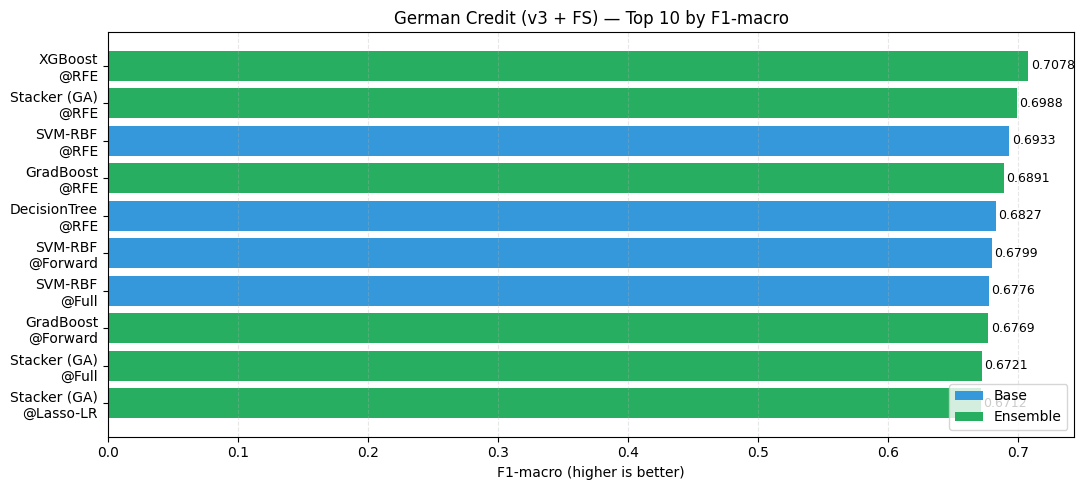

Saved → /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/results/german_v3_top10_f1macro.png


In [ ]:
top = df_all.head(10).copy()
labels = [f'{m}\n@{fs}' for m, fs in zip(top['Model'], top['FS'])]
colors = {'Base': '#3498db', 'Ensemble': '#27ae60'}
bar_colors = [colors[c] for c in top['Category']]

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(range(len(top)), top['F1-macro'], color=bar_colors)
ax.set_yticks(range(len(top))); ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel('F1-macro (higher is better)')
ax.set_title('German Credit (v3 + FS) — Top 10 by F1-macro')
for i, v in enumerate(top['F1-macro']):
    ax.text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9)
ax.grid(axis='x', alpha=0.3, ls='--')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=colors[k], label=k) for k in colors], loc='lower right')
plt.tight_layout()
plot_path = RESULTS_DIR / f'{RUN_TAG}_top10_f1macro.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {plot_path}')

### §6.4 — Winner declaration

In [ ]:
winner = df_all.iloc[0]
print('=' * 70); print('  WINNER on German Credit (by F1-macro):'); print('=' * 70)
print(f'  Model:    {winner["Model"]}')
print(f'  Category: {winner["Category"]}')
print(f'  FS:       {winner["FS"]}  ({winner["n_feat"]} features)')
print(f'  Accuracy: {winner["Accuracy"]:.4f}')
print(f'  F1:       {winner["F1"]:.4f}')
print(f'  F1-macro: {winner["F1-macro"]:.4f}')
print(f'  AUC:      {winner["AUC"]:.4f}')
print(f'  thr:      {winner["thr"]:.2f}')

stackers = df_all[df_all['Model'].str.startswith('Stacker')]
non_stacker = df_all[~df_all['Model'].str.startswith('Stacker')]
if len(stackers) and len(non_stacker):
    best_stacker = stackers.iloc[0]
    best_non_stacker = non_stacker.iloc[0]
    margin = best_stacker['F1-macro'] - best_non_stacker['F1-macro']
    print(f'\n  Best Stacker:     {best_stacker["Model"]} @ {best_stacker["FS"]}  F1-macro={best_stacker["F1-macro"]:.4f}')
    print(f'  Best non-stacker: {best_non_stacker["Model"]} @ {best_non_stacker["FS"]}  F1-macro={best_non_stacker["F1-macro"]:.4f}')
    print(f'  Stacker margin:   {margin:+.4f} F1-macro')

  WINNER on German Credit (by F1-macro):
  Model:    XGBoost
  Category: Ensemble
  FS:       RFE  (24 features)
  Accuracy: 0.7500
  F1:       0.8188
  F1-macro: 0.7078
  AUC:      0.7482
  thr:      0.54

  Best Stacker:     Stacker (GA) @ RFE  F1-macro=0.6988
  Best non-stacker: XGBoost @ RFE  F1-macro=0.7078
  Stacker margin:   -0.0090 F1-macro


### §6.5 — Recap of every artefact saved

In [ ]:
print('=' * 70); print('  Files saved by this notebook'); print('=' * 70)
import os
for d in [SUBSETS_DIR, RESULTS_DIR]:
    for p in sorted(d.glob(f'{RUN_TAG}*')):
        size = p.stat().st_size
        print(f'  {p}  ({size:,} bytes)')

  Files saved by this notebook
  /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/fs_subsets/german_v3_FS_Forward.csv  (495,495 bytes)
  /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/fs_subsets/german_v3_FS_Forward_features.csv  (441 bytes)
  /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/fs_subsets/german_v3_FS_Full.csv  (971,568 bytes)
  /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/fs_subsets/german_v3_FS_Full_features.csv  (871 bytes)
  /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/fs_subsets/german_v3_FS_Lasso_LR.csv  (933,419 bytes)
  /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/fs_subsets/german_v3_FS_Lasso_LR_features.csv  (833 bytes)
  /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/fs_subsets/german_v3_FS_RFE.csv  (479,441 bytes)
  /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/fs_subsets/german_v3_FS_RFE_features.csv  (429 bytes)
  /content/drive/MyDrive/CreditRi

## §7  Ten-measure evaluation (Chi et al., 2019)

This section adds the **ten credit-scoring measures** — Accuracy, AUC, Type I
error, Type II error, EMCC, G-Mean, Discriminant Power, F-Score, Kappa and
Youden's index — for every model and feature-selection variant.

The earlier model cells (§3, §5) store only Acc / F1 / F1-macro / AUC and
discard the predictions, so each model is **re-fitted here** to recover the full
confusion matrix. Every existing cell above is left unchanged.

### §7.1 — Ten-measure helper `ten_measures()`

In [ ]:
# §7.1 -- Ten-measure suite (Chi et al., 2019).  1 = good = positive.
from sklearn.metrics import confusion_matrix

def ten_measures(y_true, y_pred, proba, cost_bad=5.0, cost_good=1.0):
    """Ten credit-scoring measures from labels + predicted probability."""
    y_true = np.asarray(y_true, int)
    y_pred = np.asarray(y_pred, int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    e = 1e-9
    total = tp + tn + fp + fn
    sens = tp / (tp + fn + e)
    spec = tn / (tn + fp + e)
    prec = tp / (tp + fp + e)
    type1 = fn / (tp + fn + e)
    type2 = fp / (fp + tn + e)
    pi_good = (tp + fn) / (total + e)
    pi_bad  = (tn + fp) / (total + e)
    sc  = min(max(sens, e), 1 - e)
    spc = min(max(spec, e), 1 - e)
    return dict(
        Accuracy = (tp + tn) / (total + e),
        AUC      = roc_auc_score(y_true, proba),
        TypeI    = type1,
        TypeII   = type2,
        EMCC     = cost_bad * pi_bad * type2 + cost_good * pi_good * type1,
        GMean    = np.sqrt(max(sens, 0.0) * max(spec, 0.0)),
        DP       = (np.sqrt(3) / np.pi) * (np.log(sc / (1 - sc))
                                           + np.log(spc / (1 - spc))),
        FScore   = 2 * prec * sens / (prec + sens + e),
        Kappa    = cohen_kappa_score(y_true, y_pred),
        Youden   = sens + spec - 1.0,
    )

print('ten_measures() ready -- Accuracy, AUC, Type I, Type II, EMCC, '
      'G-Mean, DP, F-Score, Kappa, Youden.')

ten_measures() ready -- Accuracy, AUC, Type I, Type II, EMCC, G-Mean, DP, F-Score, Kappa, Youden.


### §7.2 — `evaluate_ten()` and `sweep_ten()` (mirror `evaluate` / `sweep_single_model`)

In [ ]:
# §7.2 -- mirror evaluate() / sweep_single_model() from §2, returning ten measures.
def evaluate_ten(model, X_tr, X_te, y_tr, y_te):
    """Fit on (X_tr, y_tr); predict on X_te; return the ten measures + thr.
    Same fit/predict and GHOST threshold logic as evaluate()."""
    model.fit(X_tr, y_tr)
    proba_test = model.predict_proba(X_te)[:, 1]
    if USE_GHOST:
        proba_train = model.predict_proba(X_tr)[:, 1]
        thr = ghostml.optimize_threshold_from_predictions(
            y_tr, proba_train, GHOST_THR, ThOpt_metrics='Kappa')
    else:
        thr = 0.5
    pred = (proba_test >= thr).astype(int)
    r = ten_measures(y_te, pred, proba_test)
    r['thr'] = thr
    return r

def sweep_ten(model_factory, name, category):
    """Run one model_factory across all 4 FS variants -- ten-measure version."""
    rows = []
    for fs_name, fs_idx in fs_methods.items():
        Xtr = X_train[:, fs_idx]; Xte = X_test[:, fs_idx]
        r = evaluate_ten(model_factory(), Xtr, Xte, y_train, y_test)
        r.update(model=name, category=category, fs=fs_name, n_features=len(fs_idx))
        rows.append(r)
        print(f'  [{category}] {name:<14s} | FS={fs_name:<8s} | '
              f'F-Score={r["FScore"]:.4f}  G-Mean={r["GMean"]:.4f}  '
              f'AUC={r["AUC"]:.4f}  Kappa={r["Kappa"]:.4f}')
    return rows

print('evaluate_ten() and sweep_ten() ready.')

evaluate_ten() and sweep_ten() ready.


### §7.3 — Base models × 4 FS (ten measures)

In [ ]:
# §7.3 -- Base models, ten measures (same factories as §3).
base_lr_10 = sweep_ten(
    lambda: maybe_smote(LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE)),
    name='LogisticReg', category='Base')
base_knn_10 = sweep_ten(
    lambda: maybe_smote(KNeighborsClassifier(n_neighbors=13, metric='manhattan')),
    name='KNN', category='Base')
base_svm_10 = sweep_ten(
    lambda: maybe_smote(SVC(C=1.0, kernel='rbf', gamma='scale',
                            probability=True, random_state=RANDOM_STATE)),
    name='SVM-RBF', category='Base')
base_dt_10 = sweep_ten(
    lambda: maybe_smote(DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)),
    name='DecisionTree', category='Base')

  [Base] LogisticReg    | FS=Full     | F-Score=0.7930  G-Mean=0.6137  AUC=0.7574  Kappa=0.2805
  [Base] LogisticReg    | FS=RFE      | F-Score=0.7807  G-Mean=0.6708  AUC=0.7705  Kappa=0.3326
  [Base] LogisticReg    | FS=Lasso-LR | F-Score=0.7972  G-Mean=0.6429  AUC=0.7570  Kappa=0.3182
  [Base] LogisticReg    | FS=Forward  | F-Score=0.7914  G-Mean=0.6473  AUC=0.7230  Kappa=0.3160
  [Base] KNN            | FS=Full     | F-Score=0.7509  G-Mean=0.5294  AUC=0.6408  Kappa=0.1341
  [Base] KNN            | FS=RFE      | F-Score=0.7845  G-Mean=0.6083  AUC=0.6870  Kappa=0.2633
  [Base] KNN            | FS=Lasso-LR | F-Score=0.7692  G-Mean=0.5606  AUC=0.6630  Kappa=0.1912
  [Base] KNN            | FS=Forward  | F-Score=0.7826  G-Mean=0.6414  AUC=0.6960  Kappa=0.2991
  [Base] SVM-RBF        | FS=Full     | F-Score=0.8194  G-Mean=0.6492  AUC=0.7628  Kappa=0.3564
  [Base] SVM-RBF        | FS=RFE      | F-Score=0.8252  G-Mean=0.6705  AUC=0.7580  Kappa=0.3873
  [Base] SVM-RBF        | FS=Lasso-LR | 

### §7.4 — Ensemble models × 4 FS (ten measures)

In [ ]:
# §7.4 -- Ensemble models, ten measures (RF and XGB reuse the per-FS tuned models).
ens_rf_10 = []
for fs_name, fs_idx in fs_methods.items():
    Xtr = X_train[:, fs_idx]; Xte = X_test[:, fs_idx]
    r = evaluate_ten(tuned_rf[fs_name], Xtr, Xte, y_train, y_test)
    r.update(model='RandomForest', category='Ensemble', fs=fs_name, n_features=len(fs_idx))
    ens_rf_10.append(r)
    print(f'  [Ensemble] RandomForest   | FS={fs_name:<8s} | '
          f'F-Score={r["FScore"]:.4f}  G-Mean={r["GMean"]:.4f}  '
          f'AUC={r["AUC"]:.4f}  Kappa={r["Kappa"]:.4f}')

ens_gb_10 = sweep_ten(
    lambda: maybe_smote(GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, min_samples_leaf=5, random_state=RANDOM_STATE)),
    name='GradBoost', category='Ensemble')

ens_xgb_10 = []
for fs_name, fs_idx in fs_methods.items():
    Xtr = X_train[:, fs_idx]; Xte = X_test[:, fs_idx]
    r = evaluate_ten(tuned_xgb[fs_name], Xtr, Xte, y_train, y_test)
    r.update(model='XGBoost', category='Ensemble', fs=fs_name, n_features=len(fs_idx))
    ens_xgb_10.append(r)
    print(f'  [Ensemble] XGBoost        | FS={fs_name:<8s} | '
          f'F-Score={r["FScore"]:.4f}  G-Mean={r["GMean"]:.4f}  '
          f'AUC={r["AUC"]:.4f}  Kappa={r["Kappa"]:.4f}')

  [Ensemble] RandomForest   | FS=Full     | F-Score=0.7757  G-Mean=0.6882  AUC=0.7852  Kappa=0.3502
  [Ensemble] RandomForest   | FS=RFE      | F-Score=0.7839  G-Mean=0.6581  AUC=0.7789  Kappa=0.3203
  [Ensemble] RandomForest   | FS=Lasso-LR | F-Score=0.7899  G-Mean=0.6544  AUC=0.7799  Kappa=0.3224
  [Ensemble] RandomForest   | FS=Forward  | F-Score=0.7433  G-Mean=0.6448  AUC=0.7295  Kappa=0.2686
  [Ensemble] GradBoost      | FS=Full     | F-Score=0.8283  G-Mean=0.6170  AUC=0.7296  Kappa=0.3394
  [Ensemble] GradBoost      | FS=RFE      | F-Score=0.8477  G-Mean=0.6294  AUC=0.7774  Kappa=0.3883
  [Ensemble] GradBoost      | FS=Lasso-LR | F-Score=0.8227  G-Mean=0.5928  AUC=0.7374  Kappa=0.3063
  [Ensemble] GradBoost      | FS=Forward  | F-Score=0.7757  G-Mean=0.6882  AUC=0.7240  Kappa=0.3502
  [Ensemble] XGBoost        | FS=Full     | F-Score=0.7584  G-Mean=0.6330  AUC=0.7642  Kappa=0.2647
  [Ensemble] XGBoost        | FS=RFE      | F-Score=0.8201  G-Mean=0.6990  AUC=0.7482  Kappa=0.4104


### §7.5 — Stacker × 4 FS (`run_stacker_v3_ten`, ten-measure copy of `run_stacker_v3`)

In [ ]:
# §7.5 -- ten-measure copy of run_stacker_v3 (cell in §5b-2). Same 5 bases,
# 5 metas, same GHOST meta-threshold and winning-meta selection (by F1-macro).
def run_stacker_v3_ten(Xtr, Xte, ytr, yte, fs_name):
    print(f'\n  -- Stacker @ FS={fs_name}  (ten-measure eval) --')
    base_models = {
        'RF'  : tuned_rf[fs_name],
        'GB'  : maybe_smote(GradientBoostingClassifier(
                   n_estimators=300, learning_rate=0.05, max_depth=5,
                   subsample=0.8, min_samples_leaf=5, random_state=RANDOM_STATE)),
        'XGB' : tuned_xgb[fs_name],
        'KNN' : maybe_smote(KNeighborsClassifier(n_neighbors=13, metric='manhattan')),
        'SVM' : maybe_smote(SVC(C=1.0, kernel='rbf', gamma='scale',
                                probability=True, random_state=RANDOM_STATE)),
    }
    oof_cols, test_cols = [], []
    for bname, bmodel in base_models.items():
        oof = cross_val_predict(bmodel, Xtr, ytr, cv=CV_FOLDS,
                                method='predict_proba')[:, 1]
        oof_cols.append(oof)
        bmodel.fit(Xtr, ytr)
        test_cols.append(bmodel.predict_proba(Xte)[:, 1])
    oof_probs  = np.column_stack(oof_cols)
    test_probs = np.column_stack(test_cols)

    best_lam = cv_best_lambda(oof_probs, ytr,
                              lambda_grid=[0.0005, 0.001, 0.002, 0.005, 0.01],
                              cv=5, n_gen=150)
    meta_models = {
        'LR'  : maybe_smote(LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE)),
        'RF'  : maybe_smote(RandomForestClassifier(n_estimators=200, max_depth=5,
                                                   random_state=RANDOM_STATE)),
        'XGB' : maybe_smote(XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=3,
                                          random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0)),
        'MLP' : maybe_smote(MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu',
                                          alpha=0.001, max_iter=500, random_state=RANDOM_STATE)),
        'GA'  : maybe_smote(MaxAccLogit(lambda_reg=best_lam, n_gen=200,
                                        scoring='f1_macro', random_state=RANDOM_STATE)),
    }
    meta_eval = {}
    for mname, meta in meta_models.items():
        meta.fit(oof_probs, ytr)
        train_p = meta.predict_proba(oof_probs)[:, 1]
        proba   = meta.predict_proba(test_probs)[:, 1]
        if USE_GHOST:
            thr = ghostml.optimize_threshold_from_predictions(
                ytr, train_p, GHOST_THR, ThOpt_metrics='Kappa')
        else:
            thr = 0.5
        pred = (proba >= thr).astype(int)
        m = ten_measures(yte, pred, proba)
        m['f1_macro'] = f1_score(yte, pred, average='macro')
        m['thr'] = thr
        meta_eval[mname] = m
        print(f'    meta {mname:<5s}  F-Score={m["FScore"]:.4f}  G-Mean={m["GMean"]:.4f}  '
              f'AUC={m["AUC"]:.4f}  Kappa={m["Kappa"]:.4f}  thr={thr:.2f}')
    best_meta = max(meta_eval, key=lambda k: meta_eval[k]['f1_macro'])
    r = {k: v for k, v in meta_eval[best_meta].items() if k != 'f1_macro'}
    r.update(model=f'Stacker ({best_meta})', category='Ensemble',
             fs=fs_name, n_features=Xtr.shape[1])
    print(f'    -> winning meta: {best_meta}  (F-Score={r["FScore"]:.4f})')
    return r

print('run_stacker_v3_ten() ready.')

run_stacker_v3_ten() ready.


In [ ]:
# §7.5 -- run the ten-measure stacker once per FS variant.
stk_full_10  = run_stacker_v3_ten(X_train[:, fs_methods['Full']],
                                  X_test[:,  fs_methods['Full']],     y_train, y_test, 'Full')
stk_rfe_10   = run_stacker_v3_ten(X_train[:, fs_methods['RFE']],
                                  X_test[:,  fs_methods['RFE']],      y_train, y_test, 'RFE')
stk_lasso_10 = run_stacker_v3_ten(X_train[:, fs_methods['Lasso-LR']],
                                  X_test[:,  fs_methods['Lasso-LR']], y_train, y_test, 'Lasso-LR')
stk_fwd_10   = run_stacker_v3_ten(X_train[:, fs_methods['Forward']],
                                  X_test[:,  fs_methods['Forward']],  y_train, y_test, 'Forward')


  -- Stacker @ FS=Full  (ten-measure eval) --
    meta LR     F-Score=0.7323  G-Mean=0.6571  AUC=0.7642  Kappa=0.2797  thr=0.50
    meta RF     F-Score=0.8041  G-Mean=0.5708  AUC=0.7298  Kappa=0.2526  thr=0.29
    meta XGB    F-Score=0.7424  G-Mean=0.6298  AUC=0.6999  Kappa=0.2478  thr=0.46
    meta MLP    F-Score=0.7529  G-Mean=0.6514  AUC=0.7276  Kappa=0.2841  thr=0.42
    meta GA     F-Score=0.7519  G-Mean=0.6711  AUC=0.7796  Kappa=0.3103  thr=0.50
    -> winning meta: GA  (F-Score=0.7519)

  -- Stacker @ FS=RFE  (ten-measure eval) --
    meta LR     F-Score=0.8198  G-Mean=0.6751  AUC=0.7680  Kappa=0.3841  thr=0.36
    meta RF     F-Score=0.7910  G-Mean=0.6925  AUC=0.7823  Kappa=0.3694  thr=0.42
    meta XGB    F-Score=0.7722  G-Mean=0.6986  AUC=0.7657  Kappa=0.3615  thr=0.49
    meta MLP    F-Score=0.7605  G-Mean=0.6637  AUC=0.7530  Kappa=0.3062  thr=0.42
    meta GA     F-Score=0.8102  G-Mean=0.6992  AUC=0.7777  Kappa=0.3981  thr=0.43
    -> winning meta: GA  (F-Score=0.8102)

  

### §7.6 — Ten-measure results table + save CSV

In [ ]:
# §7.6 -- combine, sort, display and save the ten-measure results.
all_ten = (base_lr_10 + base_knn_10 + base_svm_10 + base_dt_10
           + ens_rf_10 + ens_gb_10 + ens_xgb_10
           + [stk_full_10, stk_rfe_10, stk_lasso_10, stk_fwd_10])

df_ten = pd.DataFrame(all_ten)[
    ['category', 'model', 'fs', 'n_features',
     'Accuracy', 'AUC', 'TypeI', 'TypeII', 'EMCC',
     'GMean', 'DP', 'FScore', 'Kappa', 'Youden', 'thr']
]
df_ten.columns = ['Category', 'Model', 'FS', 'n_feat',
                  'Accuracy', 'AUC', 'Type I', 'Type II', 'EMCC',
                  'G-Mean', 'DP', 'F-Score', 'Kappa', 'Youden', 'thr']
for c in ['Accuracy', 'AUC', 'Type I', 'Type II', 'EMCC',
          'G-Mean', 'DP', 'F-Score', 'Kappa', 'Youden']:
    df_ten[c] = df_ten[c].round(4)
df_ten['thr'] = df_ten['thr'].round(2)
df_ten = df_ten.sort_values('F-Score', ascending=False).reset_index(drop=True)

print('=' * 110)
print('  §7 TEN-MEASURE EVALUATION -- every model x every FS (sorted by F-Score)')
print('=' * 110)
print(df_ten.to_string(index=False))
print('\nHigher is better EXCEPT Type I, Type II, EMCC (lower is better).')
save_csv(df_ten, RESULTS_DIR / f'{RUN_TAG}_ten_measure_results.csv')

  §7 TEN-MEASURE EVALUATION -- every model x every FS (sorted by F-Score)
Category         Model       FS  n_feat  Accuracy    AUC  Type I  Type II  EMCC  G-Mean     DP  F-Score  Kappa  Youden  thr
Ensemble     GradBoost      RFE      24     0.770 0.7774  0.0857   0.5667 0.910  0.6294 1.1572   0.8477 0.3883  0.3476 0.30
Ensemble     GradBoost     Full      48     0.745 0.7296  0.1214   0.5667 0.935  0.6170 0.9432   0.8283 0.3394  0.3119 0.38
    Base       SVM-RBF      RFE      24     0.750 0.7580  0.1571   0.4667 0.810  0.6705 0.9997   0.8252 0.3873  0.3762 0.40
Ensemble     GradBoost Lasso-LR      46     0.735 0.7374  0.1214   0.6000 0.985  0.5928 0.8675   0.8227 0.3063  0.2786 0.37
Ensemble       XGBoost      RFE      24     0.750 0.7482  0.1857   0.4000 0.730  0.6990 1.0385   0.8201 0.4104  0.4143 0.52
    Base       SVM-RBF     Full      48     0.740 0.7628  0.1571   0.5000 0.860  0.6492 0.9260   0.8194 0.3564  0.3429 0.48
    Base       SVM-RBF  Forward      24     0.735 0.7279  

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>